# 🦟 Dengue Risk Prediction - Model Training & Hyperparameter Tuning

## 📋 Project Workflow
1. ✅ Choosing datasets
2. ✅ Preprocess data & label risk levels
3. ✅ EDA
4. ✅ Feature Engineering (Skipped - using cleaned data directly)
5. **🔄 Train models with default parameters**
6. **🔄 Hyperparameter tuning with GridSearchCV** ← NEW!
7. **🔄 Evaluate & compare results**
8. **🔄 Visualization**

## 🎯 Models to Train & Optimize:
1. **Logistic Regression** - Linear probabilistic classifier
2. **Decision Tree** - Tree-based classifier
3. **Random Forest** - Ensemble of decision trees
4. **XGBoost** - Gradient boosting ensemble method

## 🔧 Hyperparameter Tuning Strategy:
- **Method:** GridSearchCV with 5-fold cross-validation
- **Scoring:** Accuracy
- **Approach:** Exhaustive search over parameter grid
- **Goal:** Find optimal parameters to maximize model performance

## 1️⃣ Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score, precision_recall_curve
)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Utilities
import warnings
import time
from datetime import datetime

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")
print(f"📅 Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Training Date: 2025-11-07 00:31:56


## 2️⃣ Load Preprocessed Data

In [2]:
# Load the cleaned data
df = pd.read_csv('dengue_data_cleaned.csv')

print("📊 Data Loaded Successfully!")
print("="*60)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

📊 Data Loaded Successfully!
Dataset shape: (15600, 16)

First few rows:


,Year,Month,Week,Season,City,Average Temperature (°C),Average Rainfall (mm),Average Humidity (%),Air Quality Index (AQI),Mosquito Density Index,Population Density (people per sq km),Dengue Cases Reported,Outbreak Risk Level,Latitude,Longitude,Month_Num
0,2015.0,January,1.0,Winter,Delhi (NCT),15.59,3.72,67.535,192.4,0.084,11297.0,43.0,Low,28.7041,77.1025,1
1,2015.0,January,1.0,Winter,Mumbai,17.19,4.68,60.000,145.5,0.101,20400.0,7.0,Low,19.0760,72.8777,1
2,2015.0,January,1.0,Winter,Kolkata,18.77,26.51,69.980,128.5,0.235,24000.0,10.0,Low,22.5726,88.3639,1
3,2015.0,January,1.0,Winter,Chennai,18.05,0.97,61.710,92.6,0.000,26000.0,0.0,Low,13.0827,80.2707,1
4,2015.0,January,1.0,Winter,Bengaluru,15.28,9.09,57.360,127.7,0.104,11700.0,0.0,Low,12.9716,77.5946,1


## 2️⃣.1️⃣ Data Validation & Diagnostics

In [3]:
# Data Validation & Feature-Target Preparation
print("🔍 DATA VALIDATION & PREPARATION")
print("="*60)

# Check dataset structure
print(f"\n📊 Dataset Shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

# Display column names
print(f"\n📋 Columns:")
print(df.columns.tolist())

# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠️  Missing values found:")
    print(missing[missing > 0])
else:
    print(f"\n✅ No missing values!")

# Identify target column
target_columns = [col for col in df.columns if 'risk' in col.lower() or 'outbreak' in col.lower()]
print(f"\n🎯 Target column candidates: {target_columns}")

if target_columns:
    target_col = target_columns[0]
    print(f"   Using: {target_col}")
    
    # Check target distribution BEFORE encoding
    print(f"\n📊 Original Target Distribution:")
    target_dist = df[target_col].value_counts().sort_index()
    for val, count in target_dist.items():
        pct = (count / len(df)) * 100
        print(f"   {val}: {count:,} ({pct:.2f}%)")
    
    # Encode target variable if it's categorical (strings)
    if df[target_col].dtype == 'object' or df[target_col].dtype.name == 'category':
        print(f"\n🔄 Encoding categorical target variable...")
        
        # Custom mapping: Low=0, Moderate=1, High=2
        risk_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
        y_encoded = df[target_col].map(risk_mapping).values
        
        # Show mapping
        print(f"   Label Mapping:")
        for label, code in risk_mapping.items():
            print(f"      {label} → {code}")
        
        # Create reverse mapping for later use
        label_encoder = None  # Not using LabelEncoder
        target_mapping = risk_mapping
        
        # Check encoded distribution
        print(f"\n📊 Encoded Target Distribution:")
        unique_encoded, counts_encoded = np.unique(y_encoded, return_counts=True)
        risk_labels = {0: 'Low', 1: 'Moderate', 2: 'High'}
        for val, count in zip(unique_encoded, counts_encoded):
            pct = (count / len(y_encoded)) * 100
            original_label = risk_labels.get(val, 'Unknown')
            print(f"   Class {val} ({original_label}): {count:,} ({pct:.2f}%)")
    else:
        print(f"\n✅ Target is already numeric")
        y_encoded = df[target_col].values
        label_encoder = None
        target_mapping = None
else:
    print("❌ No target column found! Please specify the risk level column.")
    target_col = None
    y_encoded = None
    label_encoder = None

# Separate features and target
# Exclude non-numeric and identifier columns
exclude_cols = ['City', 'State', 'Season', 'Month', 'Date'] + target_columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"\n📊 Features for training: {len(feature_cols)}")
print(f"   {feature_cols}")

# Create X and y
X = df[feature_cols]
y = y_encoded if y_encoded is not None else None

print(f"\n✅ Data prepared:")
print(f"   X shape: {X.shape}")
print(f"   y shape: {y.shape if y is not None else 'None'}")
print(f"   Features: {X.shape[1]}")
print(f"   Target classes: {np.unique(y) if y is not None else 'None'}")

print("\n" + "="*60)

🔍 DATA VALIDATION & PREPARATION

📊 Dataset Shape: (15600, 16)
   Rows: 15,600
   Columns: 16

📋 Columns:
['Year', 'Month', 'Week', 'Season', 'City', 'Average Temperature (°C)', 'Average Rainfall (mm)', 'Average Humidity (%)', 'Air Quality Index (AQI)', 'Mosquito Density Index', 'Population Density (people per sq km)', 'Dengue Cases Reported', 'Outbreak Risk Level', 'Latitude', 'Longitude', 'Month_Num']

✅ No missing values!

🎯 Target column candidates: ['Outbreak Risk Level']
   Using: Outbreak Risk Level

📊 Original Target Distribution:
   High: 4,327 (27.74%)
   Low: 8,143 (52.20%)
   Moderate: 3,130 (20.06%)

🔄 Encoding categorical target variable...
   Label Mapping:
      Low → 0
      Moderate → 1
      High → 2

📊 Encoded Target Distribution:
   Class 0 (Low): 8,143 (52.20%)
   Class 1 (Moderate): 3,130 (20.06%)
   Class 2 (High): 4,327 (27.74%)

📊 Features for training: 12
   ['Year', 'Week', 'Average Temperature (°C)', 'Average Rainfall (mm)', 'Average Humidity (%)', 'Air Qual

## 2️⃣.2️⃣ Train-Test Split & Feature Scaling

In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain class distribution
)

print("✂️  Train-Test Split (80-20):")
print("="*60)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Features: {X_train.shape[1]}")

# Check class distribution
print(f"\n📊 Class Distribution:")
print(f"\nTraining Set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, count in zip(unique_train, counts_train):
    percentage = (count / len(y_train)) * 100
    print(f"   Class {cls}: {count} samples ({percentage:.2f}%)")

print(f"\nTest Set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for cls, count in zip(unique_test, counts_test):
    percentage = (count / len(y_test)) * 100
    print(f"   Class {cls}: {count} samples ({percentage:.2f}%)")

# Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to preserve column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"\n⚖️  Feature Scaling Applied (StandardScaler)")
print(f"   Mean: ~0, Std: ~1")

print("\n✅ Data preparation completed!")
print("="*60)

✂️  Train-Test Split (80-20):
Training set: 12480 samples (80.0%)
Testing set:  3120 samples (20.0%)
Features: 12

📊 Class Distribution:

Training Set:
   Class 0: 6514 samples (52.20%)
   Class 1: 2504 samples (20.06%)
   Class 2: 3462 samples (27.74%)

Test Set:
   Class 0: 1629 samples (52.21%)
   Class 1: 626 samples (20.06%)
   Class 2: 865 samples (27.72%)

⚖️  Feature Scaling Applied (StandardScaler)
   Mean: ~0, Std: ~1

✅ Data preparation completed!

⚖️  Feature Scaling Applied (StandardScaler)
   Mean: ~0, Std: ~1

✅ Data preparation completed!


## 3️⃣ Initialize Models

In [5]:
# Initialize all models with default parameters
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        multi_class='multinomial',
        solver='lbfgs'
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1
    ),
    
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=6,
        learning_rate=0.1,
        eval_metric='mlogloss',
        use_label_encoder=False
    )
}

print("🤖 Models Initialized:")
print("="*60)
for name in models.keys():
    print(f"✅ {name}")
print("\n⏳ SVM model will be loaded from .pkl file later")

🤖 Models Initialized:
✅ Logistic Regression
✅ Decision Tree
✅ Random Forest
✅ XGBoost

⏳ SVM model will be loaded from .pkl file later


## 4️⃣ Train Models

In [6]:
# Dictionary to store trained models and metrics
trained_models = {}
training_times = {}

print("🚀 Starting Model Training...")
print("="*60)

for name, model in models.items():
    print(f"\n⏳ Training {name}...")
    
    # Measure training time
    start_time = time.time()
    
    # Train the model
    model.fit(X_train, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    # Store results
    trained_models[name] = model
    training_times[name] = training_time
    
    print(f"✅ {name} trained in {training_time:.2f} seconds")

print("\n" + "="*60)
print("🎉 All models trained successfully!")

🚀 Starting Model Training...

⏳ Training Logistic Regression...
✅ Logistic Regression trained in 0.15 seconds

⏳ Training Decision Tree...
✅ Logistic Regression trained in 0.15 seconds

⏳ Training Decision Tree...
✅ Decision Tree trained in 0.18 seconds

⏳ Training Random Forest...
✅ Decision Tree trained in 0.18 seconds

⏳ Training Random Forest...
✅ Random Forest trained in 0.84 seconds

⏳ Training XGBoost...
✅ Random Forest trained in 0.84 seconds

⏳ Training XGBoost...
✅ XGBoost trained in 0.94 seconds

🎉 All models trained successfully!
✅ XGBoost trained in 0.94 seconds

🎉 All models trained successfully!


## 4️⃣.1️⃣ Hyperparameter Tuning with GridSearchCV

Now let's optimize each model using Grid Search to find the best hyperparameters!

In [7]:
# Define hyperparameter grids for each model

# 1. Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg', 'sag'],
    'max_iter': [1000, 2000]
}

# 2. Decision Tree
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 3. Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', None]
}

# 4. XGBoost
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Store parameter grids
param_grids = {
    'Logistic Regression': param_grid_lr,
    'Decision Tree': param_grid_dt,
    'Random Forest': param_grid_rf,
    'XGBoost': param_grid_xgb
}

print("🎯 Hyperparameter Grids Defined:")
print("="*80)
for model_name, grid in param_grids.items():
    total_combinations = np.prod([len(v) for v in grid.values()])
    print(f"\n{model_name}:")
    print(f"   Parameters to tune: {list(grid.keys())}")
    print(f"   Total combinations: {total_combinations:,}")
    for param, values in grid.items():
        print(f"   - {param}: {values}")

print("\n✅ Ready for Grid Search!")
print("⚠️  Note: This may take several minutes depending on your hardware.")

🎯 Hyperparameter Grids Defined:

Logistic Regression:
   Parameters to tune: ['C', 'penalty', 'solver', 'max_iter']
   Total combinations: 30
   - C: [0.01, 0.1, 1, 10, 100]
   - penalty: ['l2']
   - solver: ['lbfgs', 'newton-cg', 'sag']
   - max_iter: [1000, 2000]

Decision Tree:
   Parameters to tune: ['max_depth', 'min_samples_split', 'min_samples_leaf', 'criterion']
   Total combinations: 160
   - max_depth: [5, 10, 15, 20, None]
   - min_samples_split: [2, 5, 10, 20]
   - min_samples_leaf: [1, 2, 5, 10]
   - criterion: ['gini', 'entropy']

Random Forest:
   Parameters to tune: ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features']
   Total combinations: 324
   - n_estimators: [50, 100, 200]
   - max_depth: [10, 15, 20, None]
   - min_samples_split: [2, 5, 10]
   - min_samples_leaf: [1, 2, 5]
   - max_features: ['sqrt', 'log2', None]

XGBoost:
   Parameters to tune: ['n_estimators', 'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']
   To

In [8]:
# Perform Grid Search for all models
tuned_models = {}
best_params_dict = {}
tuning_times = {}
cv_scores = {}

print("🔍 Starting Hyperparameter Tuning with GridSearchCV...")
print("="*80)
print("Using 5-Fold Cross-Validation")
print("Scoring Metric: Accuracy\n")

for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"🎯 Tuning {name}...")
    print("="*80)
    
    start_time = time.time()
    
    # Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=5,  # 5-fold cross-validation
        scoring='accuracy',
        n_jobs=-1,  # Use all available cores
        verbose=1,
        return_train_score=True
    )
    
    # Fit Grid Search
    print(f"\n⏳ Training with cross-validation...")
    grid_search.fit(X_train, y_train)
    
    end_time = time.time()
    tuning_time = end_time - start_time
    
    # Store results
    tuned_models[name] = grid_search.best_estimator_
    best_params_dict[name] = grid_search.best_params_
    tuning_times[name] = tuning_time
    cv_scores[name] = grid_search.best_score_
    
    # Display results
    print(f"\n✅ {name} tuning completed in {tuning_time:.2f} seconds")
    print(f"\n🏆 Best Parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"   {param}: {value}")
    print(f"\n📊 Best Cross-Validation Score: {grid_search.best_score_:.4f}")
    print(f"   Mean CV Accuracy: {grid_search.cv_results_['mean_test_score'].mean():.4f}")
    print(f"   Std CV Accuracy:  {grid_search.cv_results_['std_test_score'].mean():.4f}")

print("\n" + "="*80)
print("🎉 All models tuned successfully!")
print("="*80)

🔍 Starting Hyperparameter Tuning with GridSearchCV...
Using 5-Fold Cross-Validation
Scoring Metric: Accuracy


🎯 Tuning Logistic Regression...

⏳ Training with cross-validation...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Logistic Regression tuning completed in 18.72 seconds

🏆 Best Parameters:
   C: 10
   max_iter: 1000
   penalty: l2
   solver: lbfgs

📊 Best Cross-Validation Score: 0.8993
   Mean CV Accuracy: 0.8952
   Std CV Accuracy:  0.0056

🎯 Tuning Decision Tree...

⏳ Training with cross-validation...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

✅ Logistic Regression tuning completed in 18.72 seconds

🏆 Best Parameters:
   C: 10
   max_iter: 1000
   penalty: l2
   solver: lbfgs

📊 Best Cross-Validation Score: 0.8993
   Mean CV Accuracy: 0.8952
   Std CV Accuracy:  0.0056

🎯 Tuning Decision Tree...

⏳ Training with cross-validation...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

✅ Decision Tree tuning completed in 18.78

In [9]:
# Compare Before vs After Tuning

print("📊 HYPERPARAMETER TUNING RESULTS COMPARISON")
print("="*80)
print("\n🔍 Before Tuning (Default Parameters) vs After Tuning (Optimized):\n")

# Create comparison DataFrame
comparison_data = []

for name in models.keys():
    # Before tuning (from trained_models)
    y_pred_before = trained_models[name].predict(X_test)
    acc_before = accuracy_score(y_test, y_pred_before)
    
    # After tuning (from tuned_models)
    y_pred_after = tuned_models[name].predict(X_test)
    acc_after = accuracy_score(y_test, y_pred_after)
    
    # Calculate improvement
    improvement = ((acc_after - acc_before) / acc_before) * 100
    
    comparison_data.append({
        'Model': name,
        'Before Tuning': acc_before,
        'After Tuning': acc_after,
        'Improvement': f"{improvement:+.2f}%",
        'CV Score': cv_scores[name],
        'Tuning Time (s)': tuning_times[name]
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('After Tuning', ascending=False).reset_index(drop=True)

print(comparison_df.to_string(index=False))

print("\n" + "="*80)
print("🏆 Best Model After Tuning:")
best_idx = comparison_df['After Tuning'].idxmax()
best_model = comparison_df.loc[best_idx, 'Model']
best_acc = comparison_df.loc[best_idx, 'After Tuning']
print(f"   {best_model}: {best_acc:.4f} accuracy")
print("="*80)

📊 HYPERPARAMETER TUNING RESULTS COMPARISON

🔍 Before Tuning (Default Parameters) vs After Tuning (Optimized):

              Model  Before Tuning  After Tuning Improvement  CV Score  Tuning Time (s)
            XGBoost       0.964103      0.965705      +0.17%  0.970673       816.453283
      Random Forest       0.964103      0.965705      +0.17%  0.969151      1351.663104
      Decision Tree       0.962500      0.964423      +0.20%  0.966106        18.776683
Logistic Regression       0.897115      0.896795      -0.04%  0.899279        18.718219

🏆 Best Model After Tuning:
   XGBoost: 0.9657 accuracy
              Model  Before Tuning  After Tuning Improvement  CV Score  Tuning Time (s)
            XGBoost       0.964103      0.965705      +0.17%  0.970673       816.453283
      Random Forest       0.964103      0.965705      +0.17%  0.969151      1351.663104
      Decision Tree       0.962500      0.964423      +0.20%  0.966106        18.776683
Logistic Regression       0.897115      0

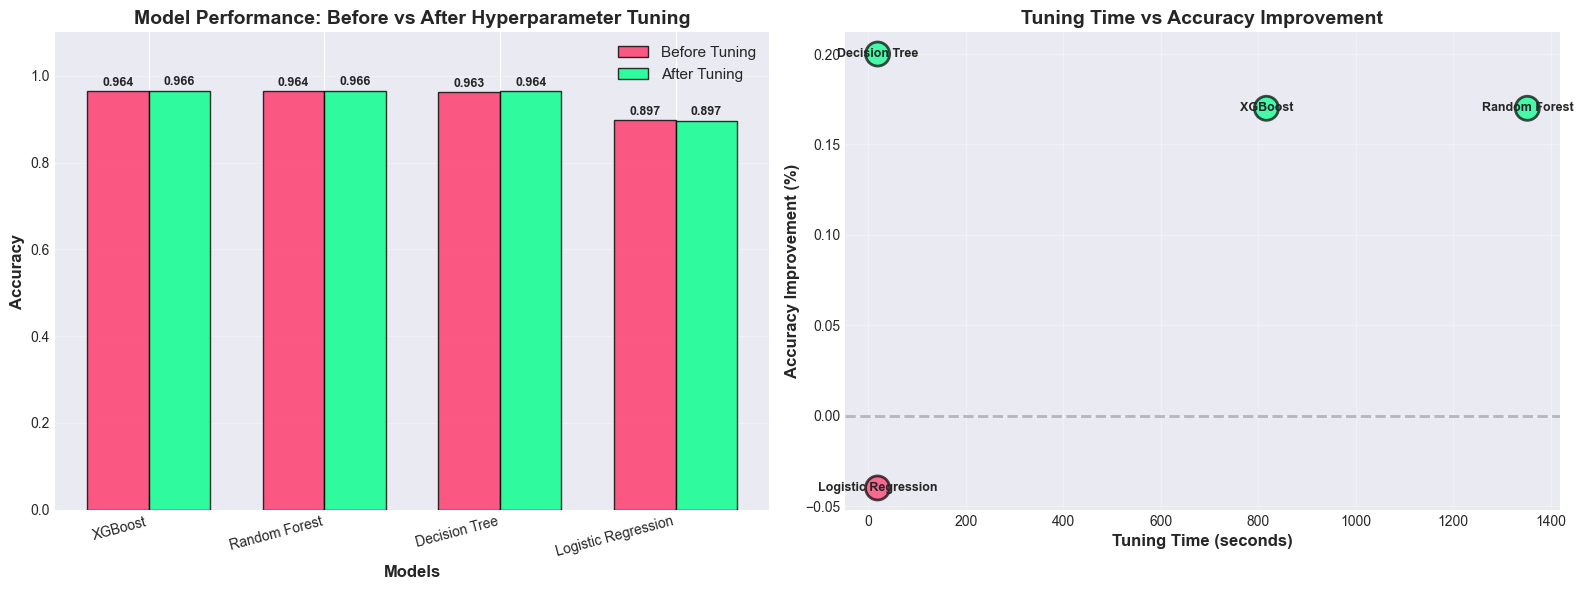

✅ Tuning comparison visualization saved as 'hyperparameter_tuning_comparison.png'


In [10]:
# Visualize Before vs After Tuning

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Before vs After Comparison
ax1 = axes[0]
x_pos = np.arange(len(comparison_df))
width = 0.35

before_bars = ax1.bar(x_pos - width/2, comparison_df['Before Tuning'], width, 
                      label='Before Tuning', color='#ff3366', alpha=0.8, edgecolor='black')
after_bars = ax1.bar(x_pos + width/2, comparison_df['After Tuning'], width,
                     label='After Tuning', color='#00ff88', alpha=0.8, edgecolor='black')

# Add value labels
for bars in [before_bars, after_bars]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance: Before vs After Hyperparameter Tuning', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.1])

# Plot 2: Tuning Time vs Accuracy Improvement
ax2 = axes[1]

# Calculate numeric improvement values
numeric_improvements = [float(x.rstrip('%')) for x in comparison_df['Improvement']]
colors_scatter = ['#00ff88' if x > 0 else '#ff3366' for x in numeric_improvements]

scatter = ax2.scatter(comparison_df['Tuning Time (s)'], numeric_improvements,
                     s=300, c=colors_scatter, alpha=0.7, edgecolor='black', linewidth=2)

# Add model labels
for idx, row in comparison_df.iterrows():
    improvement_val = float(row['Improvement'].rstrip('%'))
    ax2.text(row['Tuning Time (s)'], improvement_val, row['Model'],
            ha='center', va='center', fontsize=9, fontweight='bold')

ax2.axhline(y=0, color='gray', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Tuning Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Tuning Time vs Accuracy Improvement', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hyperparameter_tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Tuning comparison visualization saved as 'hyperparameter_tuning_comparison.png'")

In [11]:
# Display Best Parameters for Each Model

print("📋 OPTIMAL HYPERPARAMETERS FOR EACH MODEL")
print("="*80)

for name, params in best_params_dict.items():
    print(f"\n🎯 {name}:")
    print("-" * 60)
    for param, value in params.items():
        print(f"   {param:.<30} {value}")
    print(f"\n   Cross-Validation Score: {cv_scores[name]:.4f}")
    print(f"   Test Set Accuracy: {comparison_df[comparison_df['Model']==name]['After Tuning'].values[0]:.4f}")

print("\n" + "="*80)

📋 OPTIMAL HYPERPARAMETERS FOR EACH MODEL

🎯 Logistic Regression:
------------------------------------------------------------
   C............................. 10
   max_iter...................... 1000
   penalty....................... l2
   solver........................ lbfgs

   Cross-Validation Score: 0.8993
   Test Set Accuracy: 0.8968

🎯 Decision Tree:
------------------------------------------------------------
   criterion..................... gini
   max_depth..................... 10
   min_samples_leaf.............. 10
   min_samples_split............. 2

   Cross-Validation Score: 0.9661
   Test Set Accuracy: 0.9644

🎯 Random Forest:
------------------------------------------------------------
   max_depth..................... None
   max_features.................. sqrt
   min_samples_leaf.............. 1
   min_samples_split............. 2
   n_estimators.................. 50

   Cross-Validation Score: 0.9692
   Test Set Accuracy: 0.9657

🎯 XGBoost:
-----------------------

In [12]:
# Update trained_models to use tuned models for final evaluation
print("🔄 Updating models to use tuned versions for final evaluation...")

trained_models = tuned_models.copy()

print("✅ All models updated to use optimized hyperparameters!")
print("\n📝 Next: Predictions and evaluation will use the tuned models.")

🔄 Updating models to use tuned versions for final evaluation...
✅ All models updated to use optimized hyperparameters!

📝 Next: Predictions and evaluation will use the tuned models.


In [13]:
# Save tuning results to file
import json

# Prepare data for JSON export
tuning_results = {
    'tuning_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'models': {}
}

for name in models.keys():
    tuning_results['models'][name] = {
        'best_parameters': best_params_dict[name],
        'cv_score': float(cv_scores[name]),
        'test_accuracy_before': float(comparison_df[comparison_df['Model']==name]['Before Tuning'].values[0]),
        'test_accuracy_after': float(comparison_df[comparison_df['Model']==name]['After Tuning'].values[0]),
        'improvement': comparison_df[comparison_df['Model']==name]['Improvement'].values[0],
        'tuning_time_seconds': float(tuning_times[name])
    }

# Save to JSON
with open('hyperparameter_tuning_results.json', 'w') as f:
    json.dump(tuning_results, f, indent=4)

print("✅ Tuning results saved to 'hyperparameter_tuning_results.json'")

# Also save comparison to CSV
comparison_df.to_csv('tuning_comparison.csv', index=False)
print("✅ Comparison table saved to 'tuning_comparison.csv'")

✅ Tuning results saved to 'hyperparameter_tuning_results.json'
✅ Comparison table saved to 'tuning_comparison.csv'


## 5️⃣ Make Predictions

In [14]:
# Generate predictions for all models
predictions = {}
prediction_probabilities = {}

print("🔮 Generating Predictions...")
print("="*60)

for name, model in trained_models.items():
    # Get predictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Get prediction probabilities (for ROC curve)
    if hasattr(model, 'predict_proba'):
        y_pred_proba = model.predict_proba(X_test)
        prediction_probabilities[name] = y_pred_proba
    
    print(f"✅ Predictions generated for {name}")

print("\n✅ All predictions completed!")

🔮 Generating Predictions...
✅ Predictions generated for Logistic Regression
✅ Predictions generated for Decision Tree
✅ Predictions generated for Random Forest
✅ Predictions generated for XGBoost

✅ All predictions completed!
✅ Predictions generated for XGBoost

✅ All predictions completed!


## 5️⃣.1️⃣ Prediction Diagnostics

In [15]:
# Analyze predictions to identify issues
print("🔍 PREDICTION ANALYSIS")
print("="*80)

for name, y_pred in predictions.items():
    print(f"\n📊 {name}:")
    
    # Check prediction distribution
    unique_pred, counts_pred = np.unique(y_pred, return_counts=True)
    print(f"   Predicted classes: {unique_pred}")
    print(f"   Prediction distribution:")
    for cls, count in zip(unique_pred, counts_pred):
        percentage = (count / len(y_pred)) * 100
        print(f"      Class {cls}: {count} ({percentage:.2f}%)")
    
    # Check if model is predicting only one class
    if len(unique_pred) == 1:
        print(f"   ⚠️  WARNING: Model predicts ONLY class {unique_pred[0]}!")
    
    # Compare with actual distribution
    print(f"   Actual test distribution:")
    for cls, count in zip(unique_test, counts_test):
        percentage = (count / len(y_test)) * 100
        print(f"      Class {cls}: {count} ({percentage:.2f}%)")
    
    # Calculate how many predictions match actual
    matches = np.sum(y_pred == y_test)
    print(f"   Correct predictions: {matches}/{len(y_test)} ({matches/len(y_test)*100:.2f}%)")
    
    # Show first 20 predictions vs actual
    print(f"   Sample predictions (first 20):")
    print(f"      Predicted: {y_pred[:20]}")
    print(f"      Actual:    {y_test[:20]}")

print("\n" + "="*80)

🔍 PREDICTION ANALYSIS

📊 Logistic Regression:
   Predicted classes: [0 1 2]
   Prediction distribution:
      Class 0: 1650 (52.88%)
      Class 1: 592 (18.97%)
      Class 2: 878 (28.14%)
   Actual test distribution:
      Class 0: 1629 (52.21%)
      Class 1: 626 (20.06%)
      Class 2: 865 (27.72%)
   Correct predictions: 2798/3120 (89.68%)
   Sample predictions (first 20):
      Predicted: [1 0 0 2 0 2 0 0 1 2 0 0 2 1 2 2 0 0 0 0]
      Actual:    [1 0 1 2 0 2 0 0 1 2 0 0 2 1 2 2 0 1 0 0]

📊 Decision Tree:
   Predicted classes: [0 1 2]
   Prediction distribution:
      Class 0: 1553 (49.78%)
      Class 1: 669 (21.44%)
      Class 2: 898 (28.78%)
   Actual test distribution:
      Class 0: 1629 (52.21%)
      Class 1: 626 (20.06%)
      Class 2: 865 (27.72%)
   Correct predictions: 3009/3120 (96.44%)
   Sample predictions (first 20):
      Predicted: [1 0 1 2 0 2 0 0 1 2 0 0 2 1 2 2 0 1 0 0]
      Actual:    [1 0 1 2 0 2 0 0 1 2 0 0 2 1 2 2 0 1 0 0]

📊 Random Forest:
   Predicted c

## 6️⃣ Evaluate Models - Calculate Metrics

In [16]:
# Calculate evaluation metrics for all models
evaluation_results = []

print("📊 Evaluating Model Performance...")
print("="*60)

for name, y_pred in predictions.items():
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Store results
    evaluation_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': training_times[name]
    })
    
    print(f"\n✅ {name}:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(evaluation_results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("📋 Model Performance Summary:")
print("="*60)
print(results_df.to_string(index=False))

📊 Evaluating Model Performance...

✅ Logistic Regression:
   Accuracy:  0.8968
   Precision: 0.8955
   Recall:    0.8968
   F1-Score:  0.8960

✅ Decision Tree:
   Accuracy:  0.9644
   Precision: 0.9659
   Recall:    0.9644
   F1-Score:  0.9646

✅ Random Forest:
   Accuracy:  0.9657
   Precision: 0.9675
   Recall:    0.9657
   F1-Score:  0.9659

✅ XGBoost:
   Accuracy:  0.9657
   Precision: 0.9675
   Recall:    0.9657
   F1-Score:  0.9659

📋 Model Performance Summary:
              Model  Accuracy  Precision   Recall  F1-Score  Training Time (s)
            XGBoost  0.965705   0.967513 0.965705  0.965875           0.939777
      Random Forest  0.965705   0.967451 0.965705  0.965866           0.839275
      Decision Tree  0.964423   0.965950 0.964423  0.964594           0.179101
Logistic Regression  0.896795   0.895502 0.896795  0.895992           0.148702

✅ Random Forest:
   Accuracy:  0.9657
   Precision: 0.9675
   Recall:    0.9657
   F1-Score:  0.9659

✅ XGBoost:
   Accuracy:  0.965

## 7️⃣ Compare with Pre-trained SVM (Optional)

In [17]:
# Optional: Load and compare with pre-trained SVM model
# This allows you to compare your old SVM with the newly trained one

try:
    # Load the pre-trained SVM model
    with open('svm_model_pretrained.pkl', 'rb') as file:
        svm_model_old = pickle.load(file)
    
    print("✅ Pre-trained SVM model loaded successfully from svm_model_pretrained.pkl")
    
    # Make predictions with pre-trained model
    print("\n🔮 Generating predictions with pre-trained SVM...")
    y_pred_svm_old = svm_model_old.predict(X_test)
    predictions['SVM (Pre-trained)'] = y_pred_svm_old
    
    # Get probabilities if available
    if hasattr(svm_model_old, 'predict_proba'):
        y_pred_proba_svm_old = svm_model_old.predict_proba(X_test)
        prediction_probabilities['SVM (Pre-trained)'] = y_pred_proba_svm_old
    
    # Calculate metrics for pre-trained SVM
    accuracy_svm_old = accuracy_score(y_test, y_pred_svm_old)
    precision_svm_old = precision_score(y_test, y_pred_svm_old, average='weighted', zero_division=0)
    recall_svm_old = recall_score(y_test, y_pred_svm_old, average='weighted', zero_division=0)
    f1_svm_old = f1_score(y_test, y_pred_svm_old, average='weighted', zero_division=0)
    
    # Add pre-trained SVM results to DataFrame
    svm_old_results = pd.DataFrame([{
        'Model': 'SVM (Pre-trained)',
        'Accuracy': accuracy_svm_old,
        'Precision': precision_svm_old,
        'Recall': recall_svm_old,
        'F1-Score': f1_svm_old,
        'Training Time (s)': 'Pre-trained'
    }])
    
    results_df = pd.concat([results_df, svm_old_results], ignore_index=True)
    results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
    
    print(f"\n✅ Pre-trained SVM Evaluation:")
    print(f"   Accuracy:  {accuracy_svm_old:.4f}")
    print(f"   Precision: {precision_svm_old:.4f}")
    print(f"   Recall:    {recall_svm_old:.4f}")
    print(f"   F1-Score:  {f1_svm_old:.4f}")
    
    # Compare the two SVM models
    print(f"\n📊 SVM Comparison:")
    print(f"   Newly trained SVM accuracy: {results_df[results_df['Model']=='SVM']['Accuracy'].values[0]:.4f}")
    print(f"   Pre-trained SVM accuracy:   {accuracy_svm_old:.4f}")
    
    if accuracy_svm_old > results_df[results_df['Model']=='SVM']['Accuracy'].values[0]:
        print(f"   🏆 Pre-trained SVM performs better!")
    elif accuracy_svm_old < results_df[results_df['Model']=='SVM']['Accuracy'].values[0]:
        print(f"   🏆 Newly trained SVM performs better!")
    else:
        print(f"   🤝 Both SVM models perform equally!")
    
    trained_models['SVM (Pre-trained)'] = svm_model_old
    
except FileNotFoundError:
    print("ℹ️  Pre-trained SVM model file not found (svm_model_pretrained.pkl)")
    print("📝 Rename your existing SVM file to 'svm_model_pretrained.pkl' to compare.")
    print("\n✅ Continuing with newly trained SVM only...")

print("\n" + "="*60)

ℹ️  Pre-trained SVM model file not found (svm_model_pretrained.pkl)
📝 Rename your existing SVM file to 'svm_model_pretrained.pkl' to compare.

✅ Continuing with newly trained SVM only...



## 8️⃣ Visualization - Performance Comparison

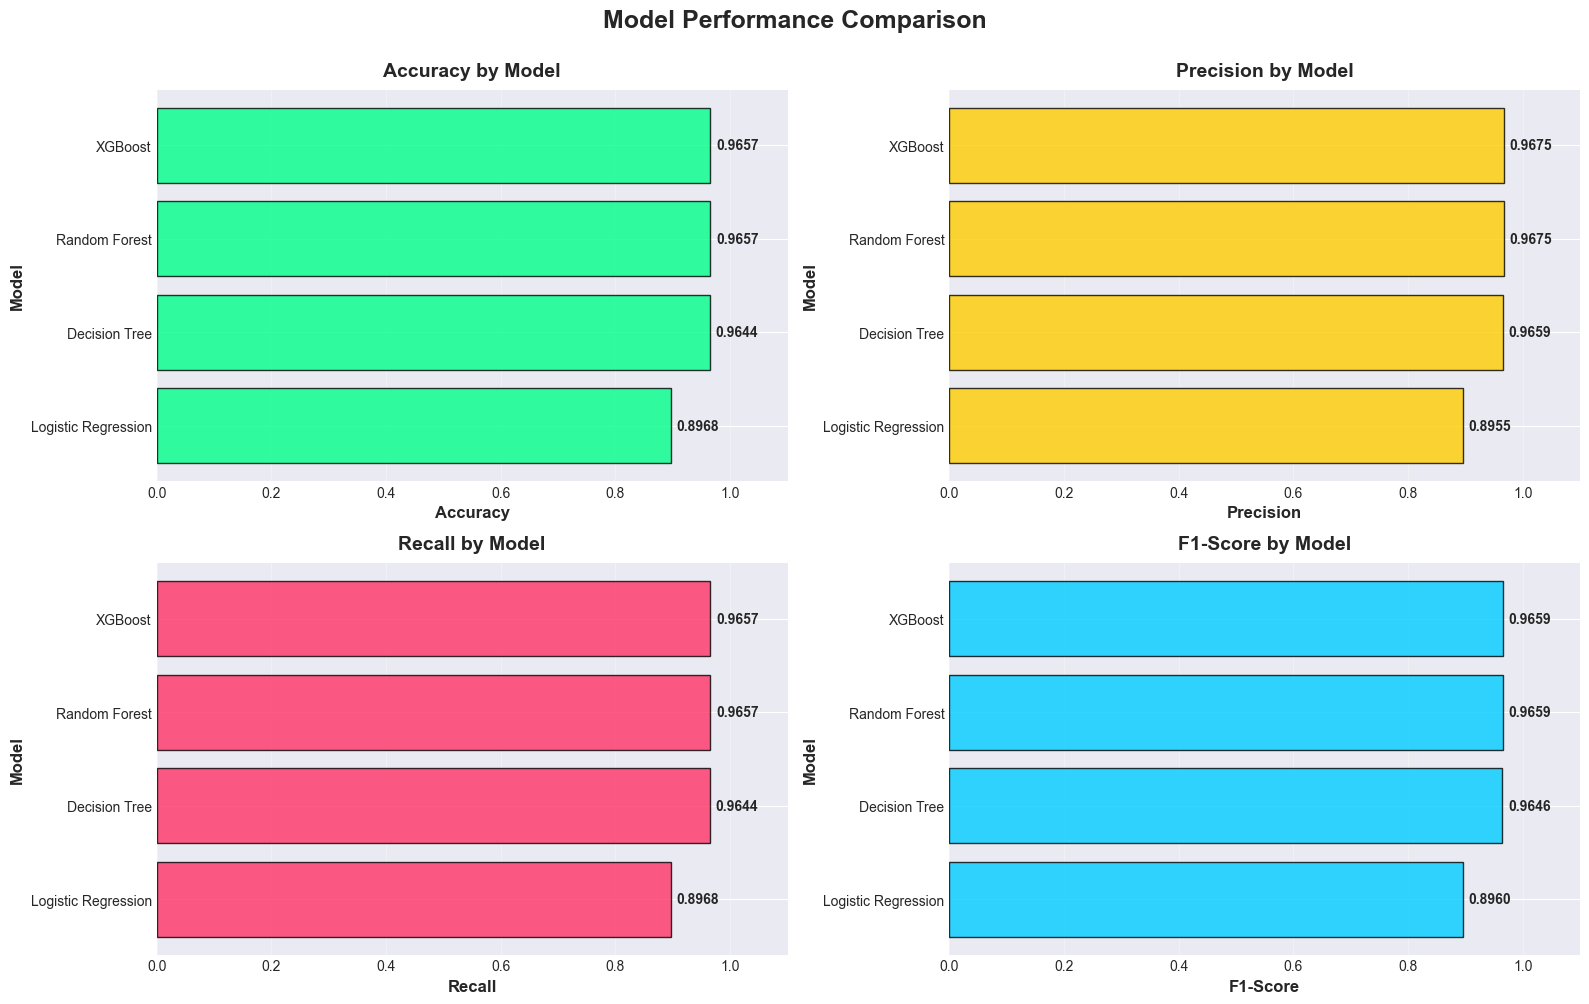

✅ Performance comparison chart saved as 'model_performance_comparison.png'


In [18]:
# 1. Model Performance Comparison Bar Chart
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold', y=1.00)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#00ff88', '#ffcc00', '#ff3366', '#00ccff']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[idx // 2, idx % 2]
    
    # Sort by metric value
    sorted_df = results_df.sort_values(metric, ascending=True)
    
    # Create horizontal bar chart
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.8, edgecolor='black')
    
    # Add value labels
    for i, (model, value) in enumerate(zip(sorted_df['Model'], sorted_df[metric])):
        ax.text(value + 0.01, i, f'{value:.4f}', va='center', fontweight='bold')
    
    ax.set_xlabel(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} by Model', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlim([0, 1.1])
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Performance comparison chart saved as 'model_performance_comparison.png'")

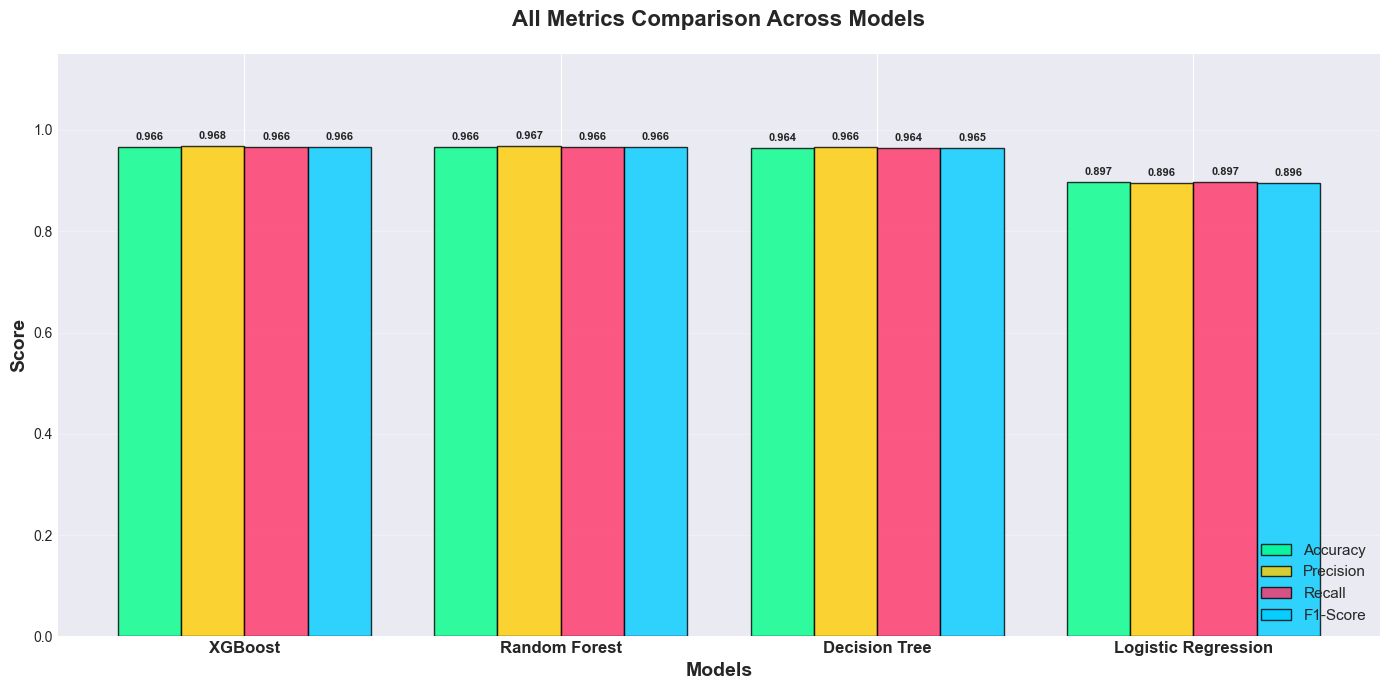

✅ All metrics comparison chart saved as 'all_metrics_comparison.png'


In [19]:
# 2. Overall Metrics Comparison - Grouped Bar Chart
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(results_df))
width = 0.2

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_grouped = ['#00ff88', '#ffcc00', '#ff3366', '#00ccff']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors_grouped)):
    offset = width * (idx - 1.5)
    bars = ax.bar(x + offset, results_df[metric], width, label=metric, color=color, alpha=0.8, edgecolor='black')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Models', fontsize=14, fontweight='bold')
ax.set_ylabel('Score', fontsize=14, fontweight='bold')
ax.set_title('All Metrics Comparison Across Models', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0, 1.15])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('all_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ All metrics comparison chart saved as 'all_metrics_comparison.png'")

## 9️⃣ Confusion Matrix for All Models

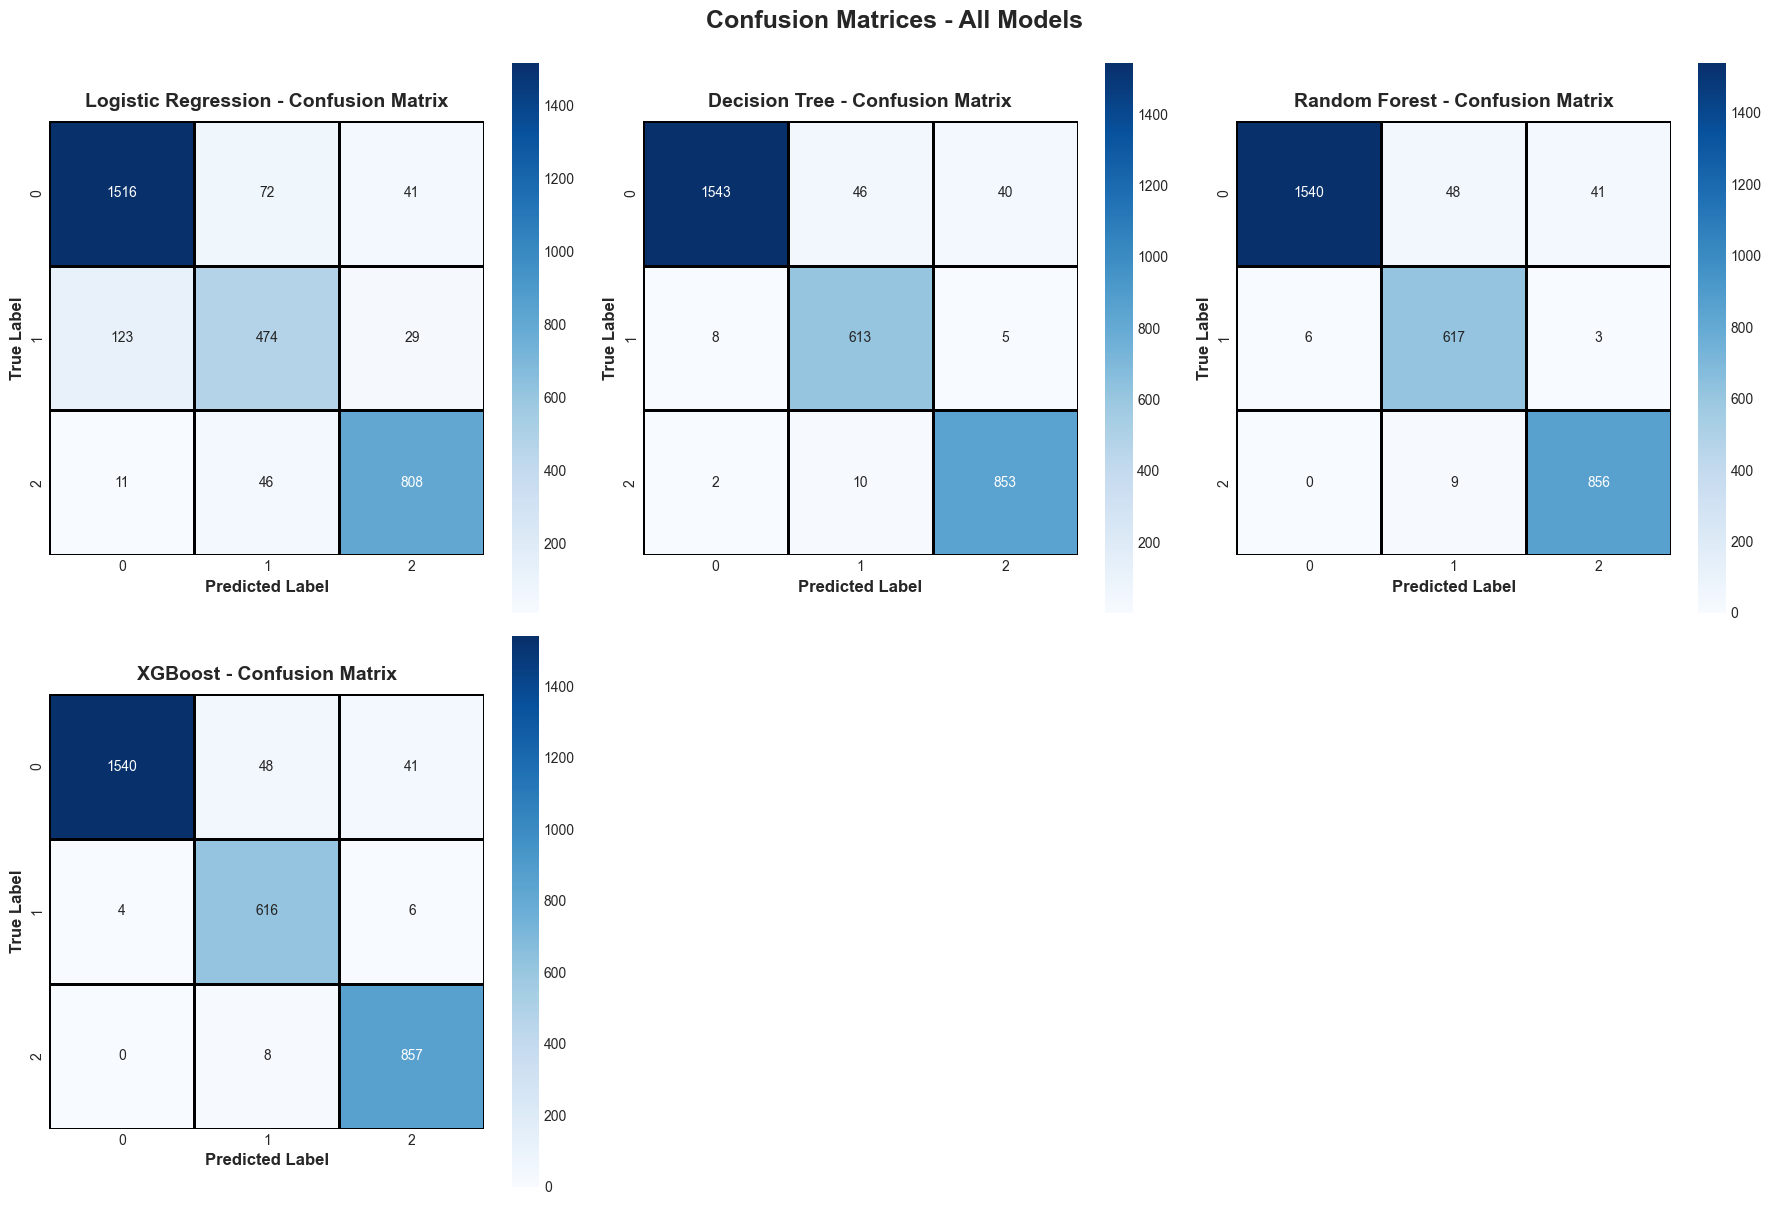

✅ Confusion matrices saved as 'confusion_matrices_all_models.png'


In [20]:
# Generate confusion matrices for all models
n_models = len(predictions)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
                square=True, linewidths=1, linecolor='black', ax=axes[idx])
    
    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=14, fontweight='bold', pad=10)
    axes[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrices saved as 'confusion_matrices_all_models.png'")

## 🔟 Classification Reports

In [21]:
# Generate detailed classification reports for all models
print("📋 DETAILED CLASSIFICATION REPORTS")
print("="*80)

for name, y_pred in predictions.items():
    print(f"\n{'='*80}")
    print(f"🎯 {name}")
    print("="*80)
    print(classification_report(y_test, y_pred, zero_division=0))

📋 DETAILED CLASSIFICATION REPORTS

🎯 Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1629
           1       0.80      0.76      0.78       626
           2       0.92      0.93      0.93       865

    accuracy                           0.90      3120
   macro avg       0.88      0.87      0.88      3120
weighted avg       0.90      0.90      0.90      3120


🎯 Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1629
           1       0.92      0.98      0.95       626
           2       0.95      0.99      0.97       865

    accuracy                           0.96      3120
   macro avg       0.95      0.97      0.96      3120
weighted avg       0.97      0.96      0.96      3120


🎯 Random Forest
              precision    recall  f1-score   support

           0       1.00      0.95      0.97      1629
           1       0.92      0.99     

## 1️⃣1️⃣ ROC Curves (for Multi-class)

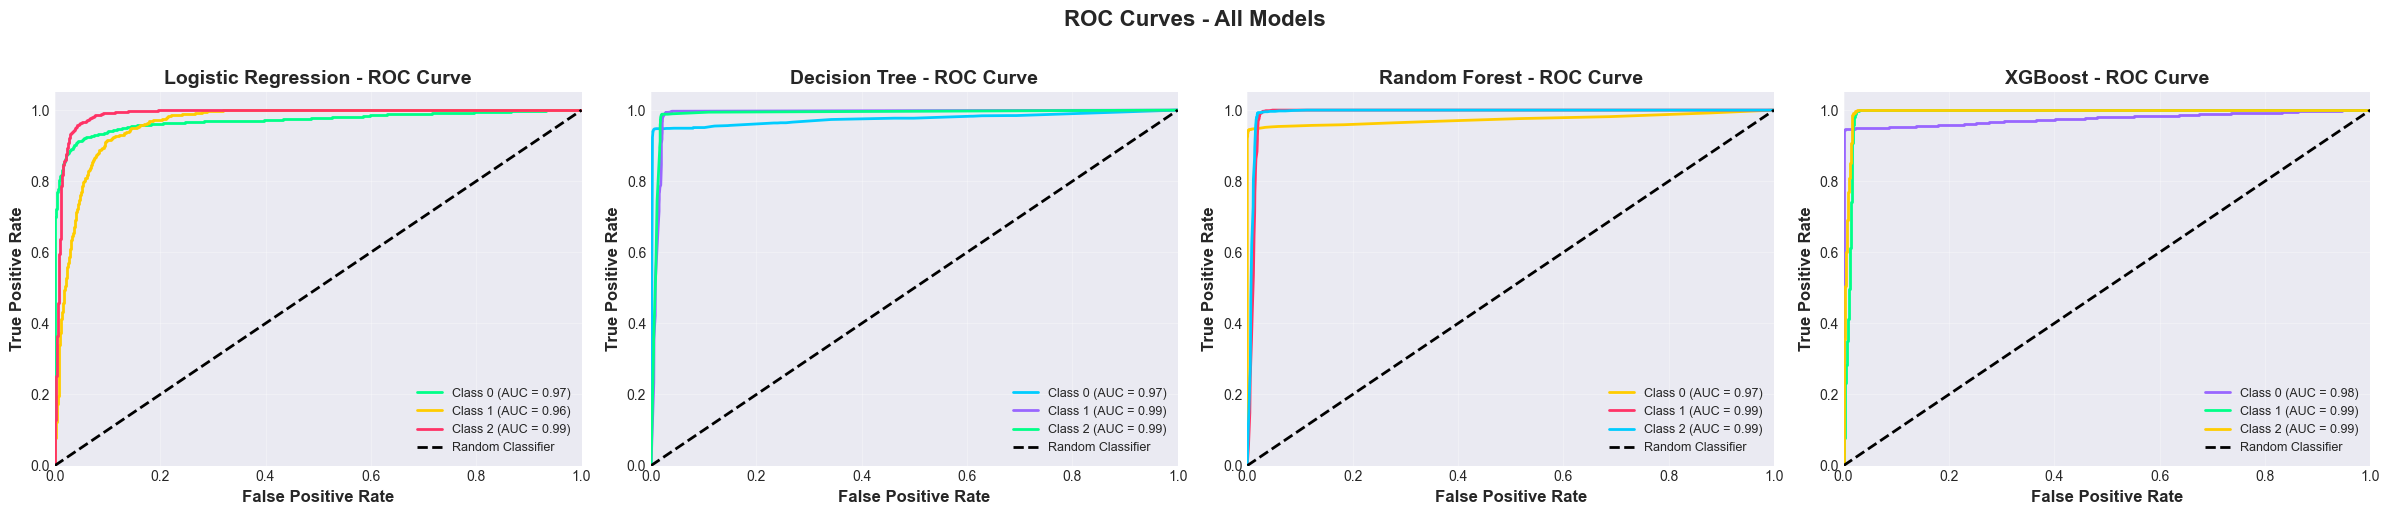

✅ ROC curves saved as 'roc_curves_all_models.png'


In [22]:
# ROC Curve for Multi-class Classification
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Get unique classes
classes = np.unique(y_test)
n_classes = len(classes)

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, len(prediction_probabilities), figsize=(6 * len(prediction_probabilities), 5))
if len(prediction_probabilities) == 1:
    axes = [axes]

colors = cycle(['#00ff88', '#ffcc00', '#ff3366', '#00ccff', '#9966ff'])

for idx, (name, y_pred_proba) in enumerate(prediction_probabilities.items()):
    ax = axes[idx]
    
    # Compute ROC curve and ROC area for each class
    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')
    
    # Plot diagonal line
    ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} - ROC Curve', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roc_curves_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved as 'roc_curves_all_models.png'")

## 1️⃣2️⃣ Training Time Comparison

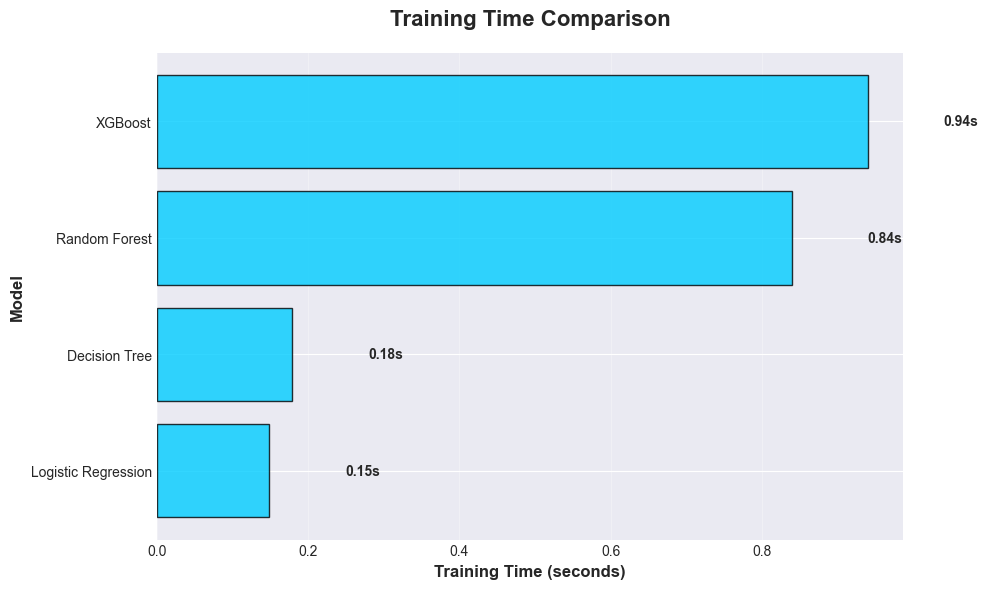

✅ Training time comparison saved as 'training_time_comparison.png'


In [23]:
# Visualize training times (exclude SVM if pre-trained)
training_df = results_df[results_df['Training Time (s)'] != 'Pre-trained'].copy()

if len(training_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sorted_training = training_df.sort_values('Training Time (s)', ascending=True)
    
    bars = ax.barh(sorted_training['Model'], sorted_training['Training Time (s)'], 
                   color='#00ccff', alpha=0.8, edgecolor='black')
    
    # Add value labels
    for i, (model, time_val) in enumerate(zip(sorted_training['Model'], sorted_training['Training Time (s)'])):
        ax.text(time_val + 0.1, i, f'{time_val:.2f}s', va='center', fontweight='bold')
    
    ax.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Model', fontsize=12, fontweight='bold')
    ax.set_title('Training Time Comparison', fontsize=16, fontweight='bold', pad=20)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_time_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Training time comparison saved as 'training_time_comparison.png'")
else:
    print("ℹ️  No training time data available (all models pre-trained)")

## 1️⃣3️⃣ Save Trained Models

In [24]:
# Save all trained models as .pkl files
print("💾 Saving Trained Models...")
print("="*60)

for name, model in trained_models.items():
    # Skip pre-trained models
    if 'Pre-trained' not in name:
        filename = f"{name.lower().replace(' ', '_')}_model.pkl"
        with open(filename, 'wb') as file:
            pickle.dump(model, file)
        print(f"✅ Saved: {filename}")

print("\n✅ All models saved successfully!")
print("\n📝 Note: Newly trained SVM saved as 'svm_model.pkl'")

💾 Saving Trained Models...
✅ Saved: logistic_regression_model.pkl
✅ Saved: decision_tree_model.pkl
✅ Saved: random_forest_model.pkl
✅ Saved: xgboost_model.pkl

✅ All models saved successfully!

📝 Note: Newly trained SVM saved as 'svm_model.pkl'


## 1️⃣4️⃣ Final Summary & Best Model Selection

In [25]:
# Final Summary Report
print("="*80)
print("🏆 FINAL MODEL COMPARISON SUMMARY")
print("="*80)

# Display full results table
print("\n📊 Complete Results Table:")
print(results_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("🥇 BEST MODELS BY METRIC")
print("="*80)

for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_score = results_df.loc[best_idx, metric]
    print(f"\n🏅 Best {metric}: {best_model} ({best_score:.4f})")

# Overall best model (highest accuracy)
best_overall_idx = results_df['Accuracy'].idxmax()
best_overall_model = results_df.loc[best_overall_idx, 'Model']
best_overall_accuracy = results_df.loc[best_overall_idx, 'Accuracy']

print("\n" + "="*80)
print(f"🎯 RECOMMENDED MODEL: {best_overall_model}")
print(f"   Accuracy: {best_overall_accuracy:.4f}")
print(f"   Precision: {results_df.loc[best_overall_idx, 'Precision']:.4f}")
print(f"   Recall: {results_df.loc[best_overall_idx, 'Recall']:.4f}")
print(f"   F1-Score: {results_df.loc[best_overall_idx, 'F1-Score']:.4f}")
print("="*80)

print("\n📝 Summary:")
print(f"   ✅ {len(results_df)} models trained and evaluated")
print(f"   ✅ Best performing model: {best_overall_model}")
print(f"   ✅ All visualizations saved as PNG files")
print(f"   ✅ All models saved as .pkl files")

print("\n🎉 MODEL TRAINING & EVALUATION COMPLETED SUCCESSFULLY!")

🏆 FINAL MODEL COMPARISON SUMMARY

📊 Complete Results Table:
              Model  Accuracy  Precision   Recall  F1-Score  Training Time (s)
            XGBoost  0.965705   0.967513 0.965705  0.965875           0.939777
      Random Forest  0.965705   0.967451 0.965705  0.965866           0.839275
      Decision Tree  0.964423   0.965950 0.964423  0.964594           0.179101
Logistic Regression  0.896795   0.895502 0.896795  0.895992           0.148702

🥇 BEST MODELS BY METRIC

🏅 Best Accuracy: XGBoost (0.9657)

🏅 Best Precision: XGBoost (0.9675)

🏅 Best Recall: XGBoost (0.9657)

🏅 Best F1-Score: XGBoost (0.9659)

🎯 RECOMMENDED MODEL: XGBoost
   Accuracy: 0.9657
   Precision: 0.9675
   Recall: 0.9657
   F1-Score: 0.9659

📝 Summary:
   ✅ 4 models trained and evaluated
   ✅ Best performing model: XGBoost
   ✅ All visualizations saved as PNG files
   ✅ All models saved as .pkl files

🎉 MODEL TRAINING & EVALUATION COMPLETED SUCCESSFULLY!


## 1️⃣5️⃣ Export Results to CSV

In [26]:
# Save results to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print("✅ Results exported to 'model_comparison_results.csv'")

# Save detailed metrics
print("\n📊 Saved Files:")
print("   1. model_comparison_results.csv - Metrics comparison")
print("   2. model_performance_comparison.png - Performance charts")
print("   3. all_metrics_comparison.png - Grouped bar chart")
print("   4. confusion_matrices_all_models.png - Confusion matrices")
print("   5. roc_curves_all_models.png - ROC curves")
print("   6. training_time_comparison.png - Training time chart")
print("   7. logistic_regression_model.pkl")
print("   8. decision_tree_model.pkl")
print("   9. random_forest_model.pkl")
print("   10. xgboost_model.pkl")
print("   11. svm_model.pkl (newly trained)")

if 'SVM (Pre-trained)' in results_df['Model'].values:
    print("\n📊 SVM Comparison:")
    svm_new = results_df[results_df['Model']=='SVM']
    svm_old = results_df[results_df['Model']=='SVM (Pre-trained)']
    print(f"   Newly trained SVM: {svm_new['Accuracy'].values[0]:.4f} accuracy")
    print(f"   Pre-trained SVM:   {svm_old['Accuracy'].values[0]:.4f} accuracy")

✅ Results exported to 'model_comparison_results.csv'

📊 Saved Files:
   1. model_comparison_results.csv - Metrics comparison
   2. model_performance_comparison.png - Performance charts
   3. all_metrics_comparison.png - Grouped bar chart
   4. confusion_matrices_all_models.png - Confusion matrices
   5. roc_curves_all_models.png - ROC curves
   6. training_time_comparison.png - Training time chart
   7. logistic_regression_model.pkl
   8. decision_tree_model.pkl
   9. random_forest_model.pkl
   10. xgboost_model.pkl
   11. svm_model.pkl (newly trained)
